GPU Check

In [ ]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install Dependencies

In [ ]:
!pip install ultralytics matplotlib seaborn opencv-python

    1.2/1.2 MB 32.8 MB/s eta 0:00:00


Load Dataset Path

In [ ]:
dataset_path = "/content/drive/MyDrive/Traffic-signs dataset"

Fix data.yaml

In [ ]:
import yaml

yaml_path = dataset_path + "/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['path'] = dataset_path

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Updated YAML:", data)

Updated YAML: {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 74, 'names': ['-', '- 50- probability of horizontal flip', '- 50- probability of vertical flip', '- Random Gaussian blur of between 0 and 3.25 pixels', '- Randomly crop between 0 and 33 percent of the image', '- annotate- and create datasets', '- collaborate with your team on computer vision projects', '- collect - organize images', '- export- train- and deploy computer vision models', '- understand and search unstructured image data', '- use active learning to improve your dataset over time', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', 'For state of the art Computer Vision training notebooks you can use with this dat

Train YOLOv8 (GPU Optimized)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=dataset_path + "/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0   # GPU
)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 =� Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Traffic-signs dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hs

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cf58bccbe00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,

Visualize Training Results

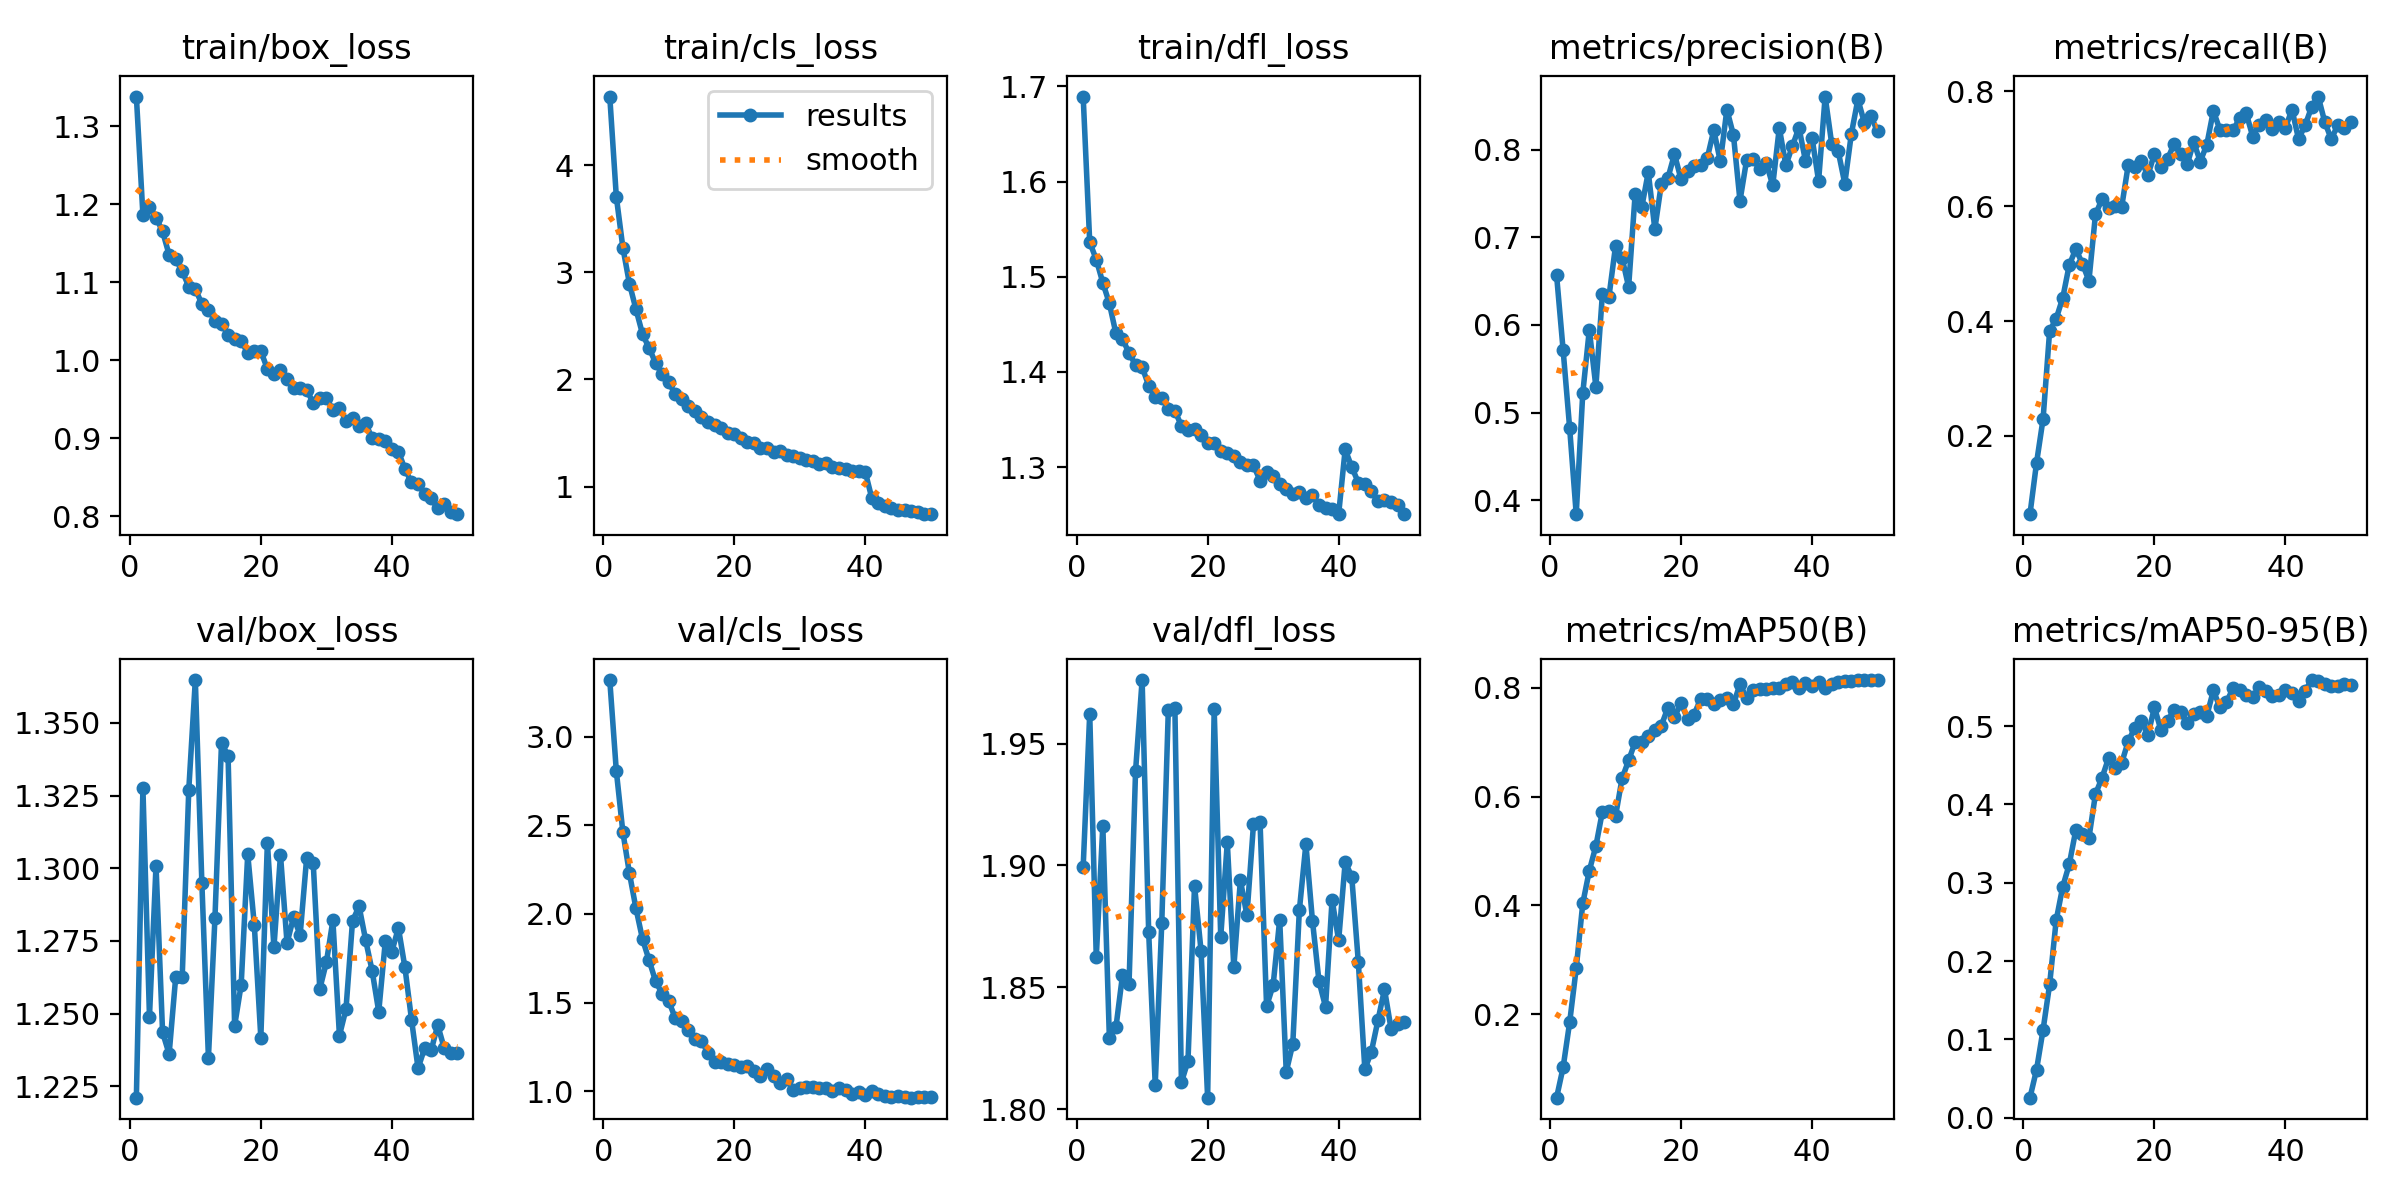

In [ ]:
from IPython.display import Image, display

display(Image(filename='runs/detect/train/results.png'))

Confusion Matrix

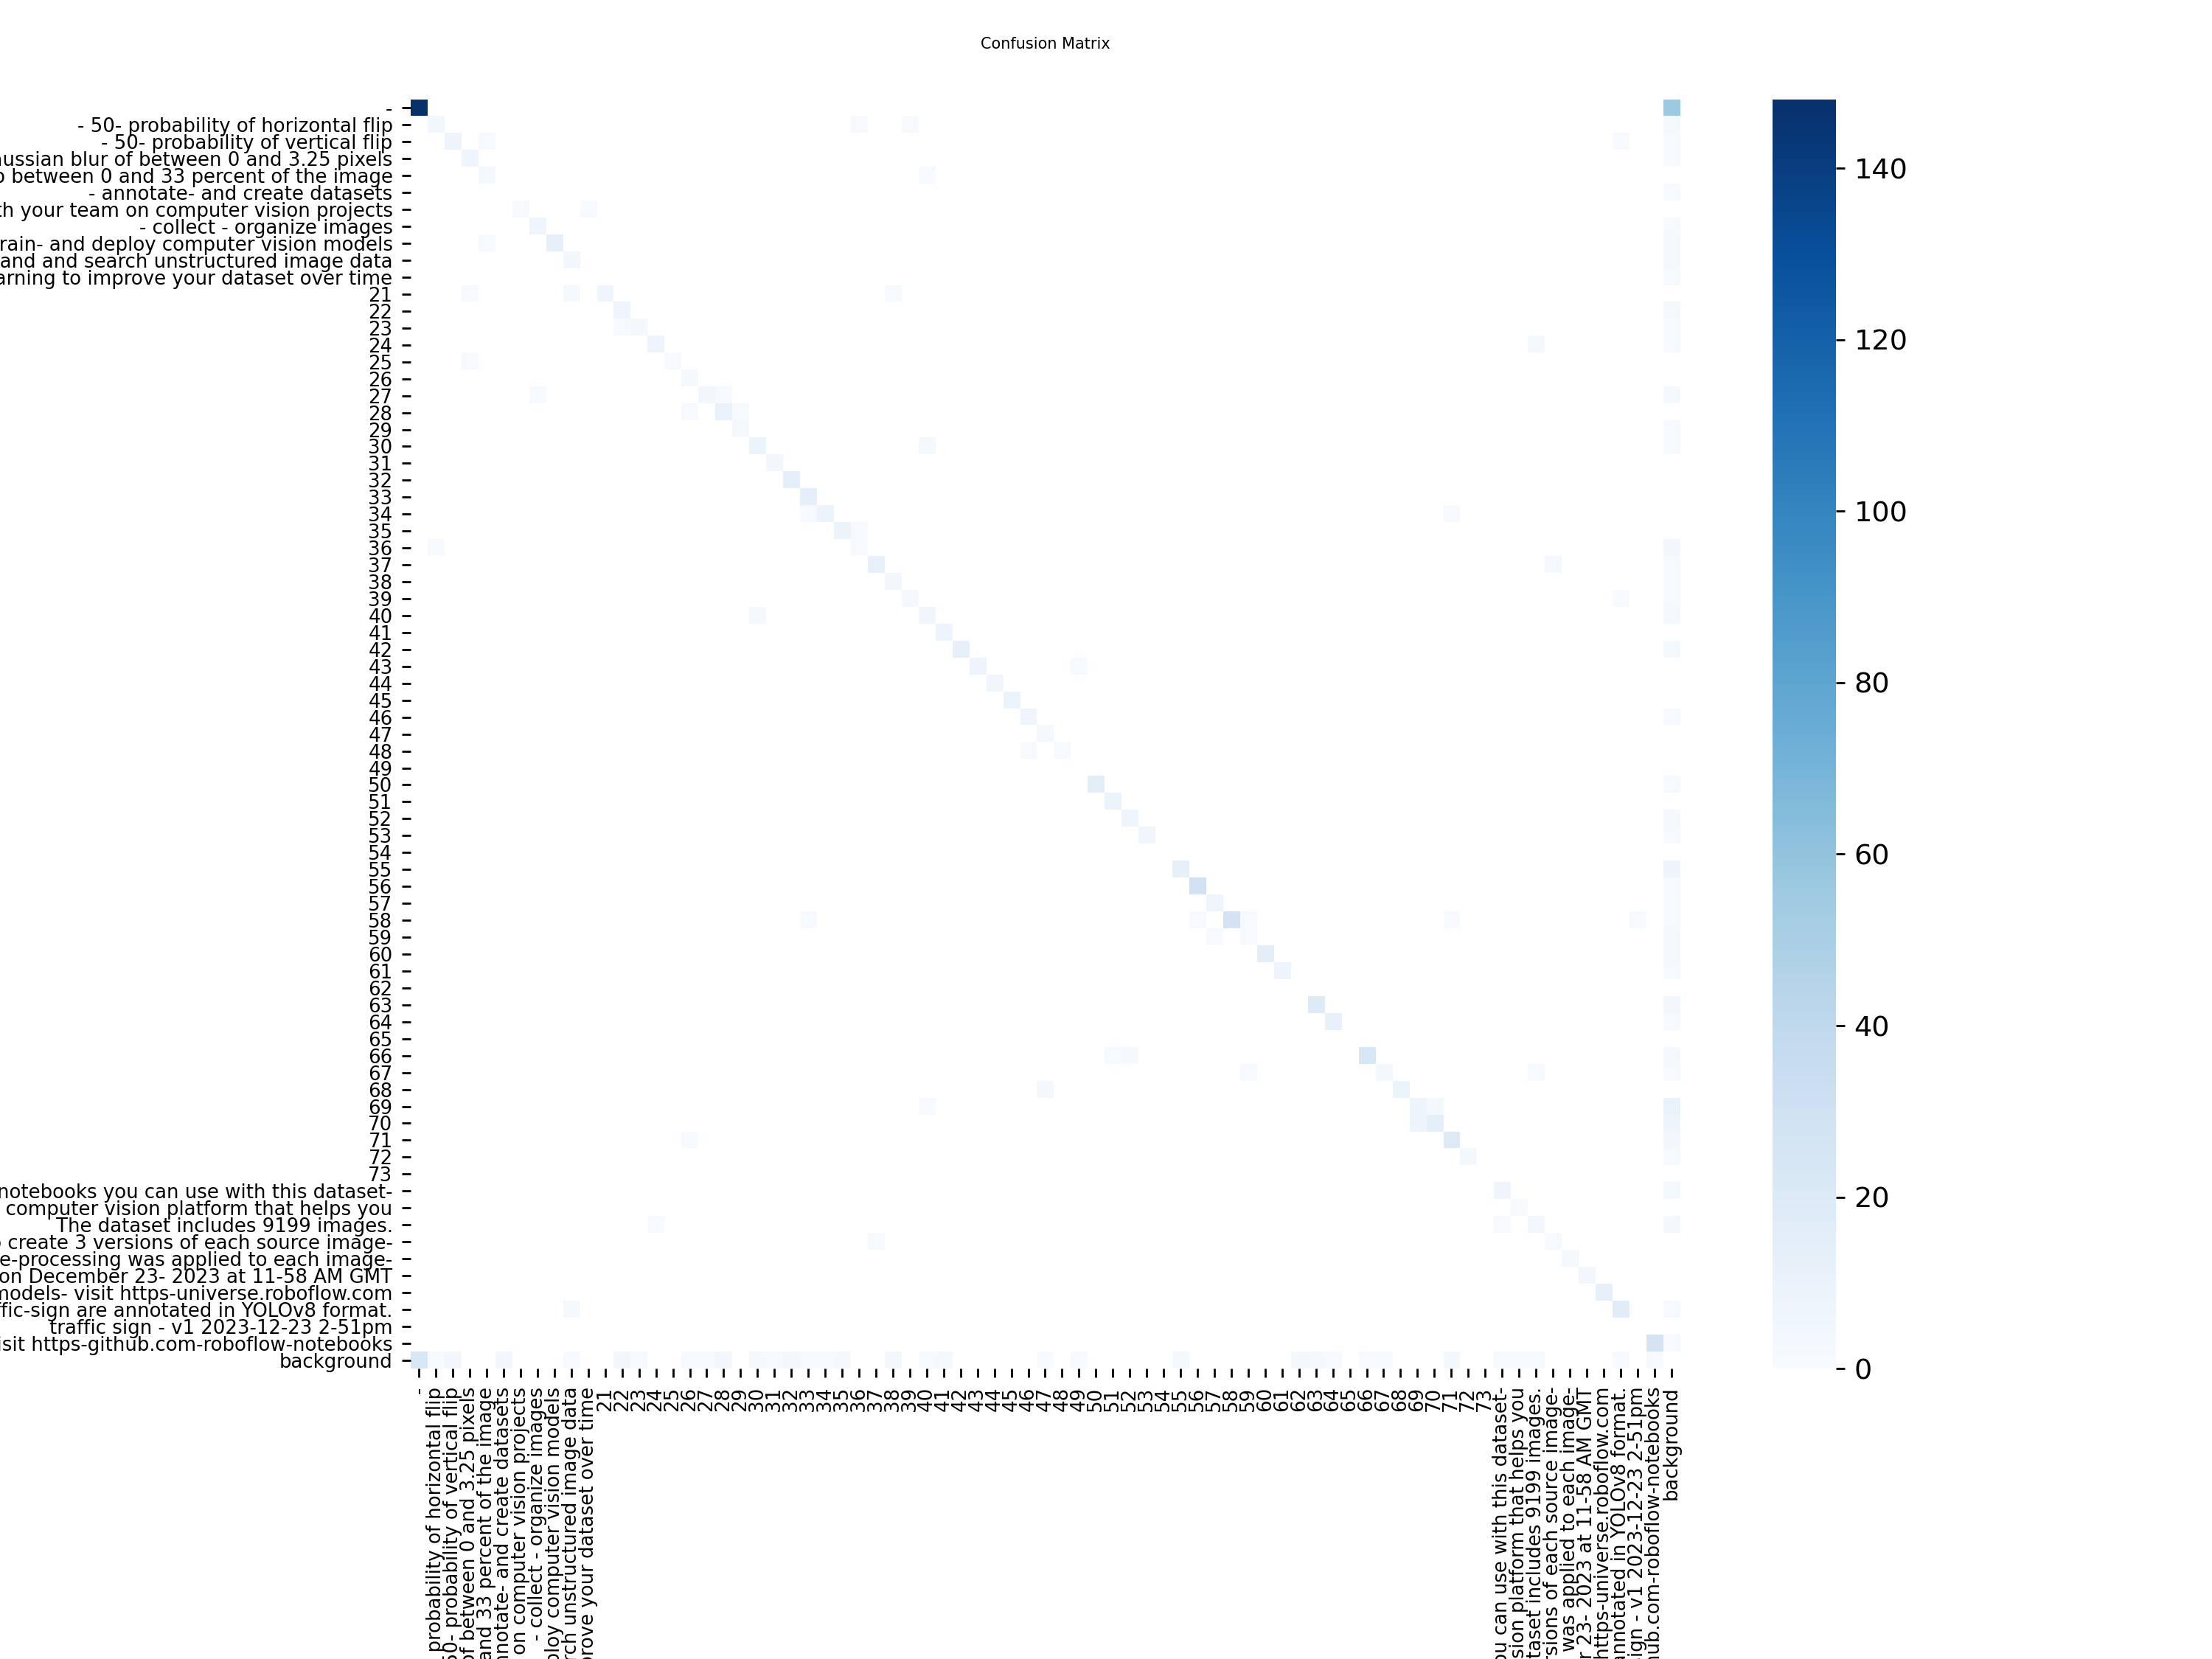

In [ ]:
display(Image(filename='runs/detect/train/confusion_matrix.png'))

Precision-Recall Curve

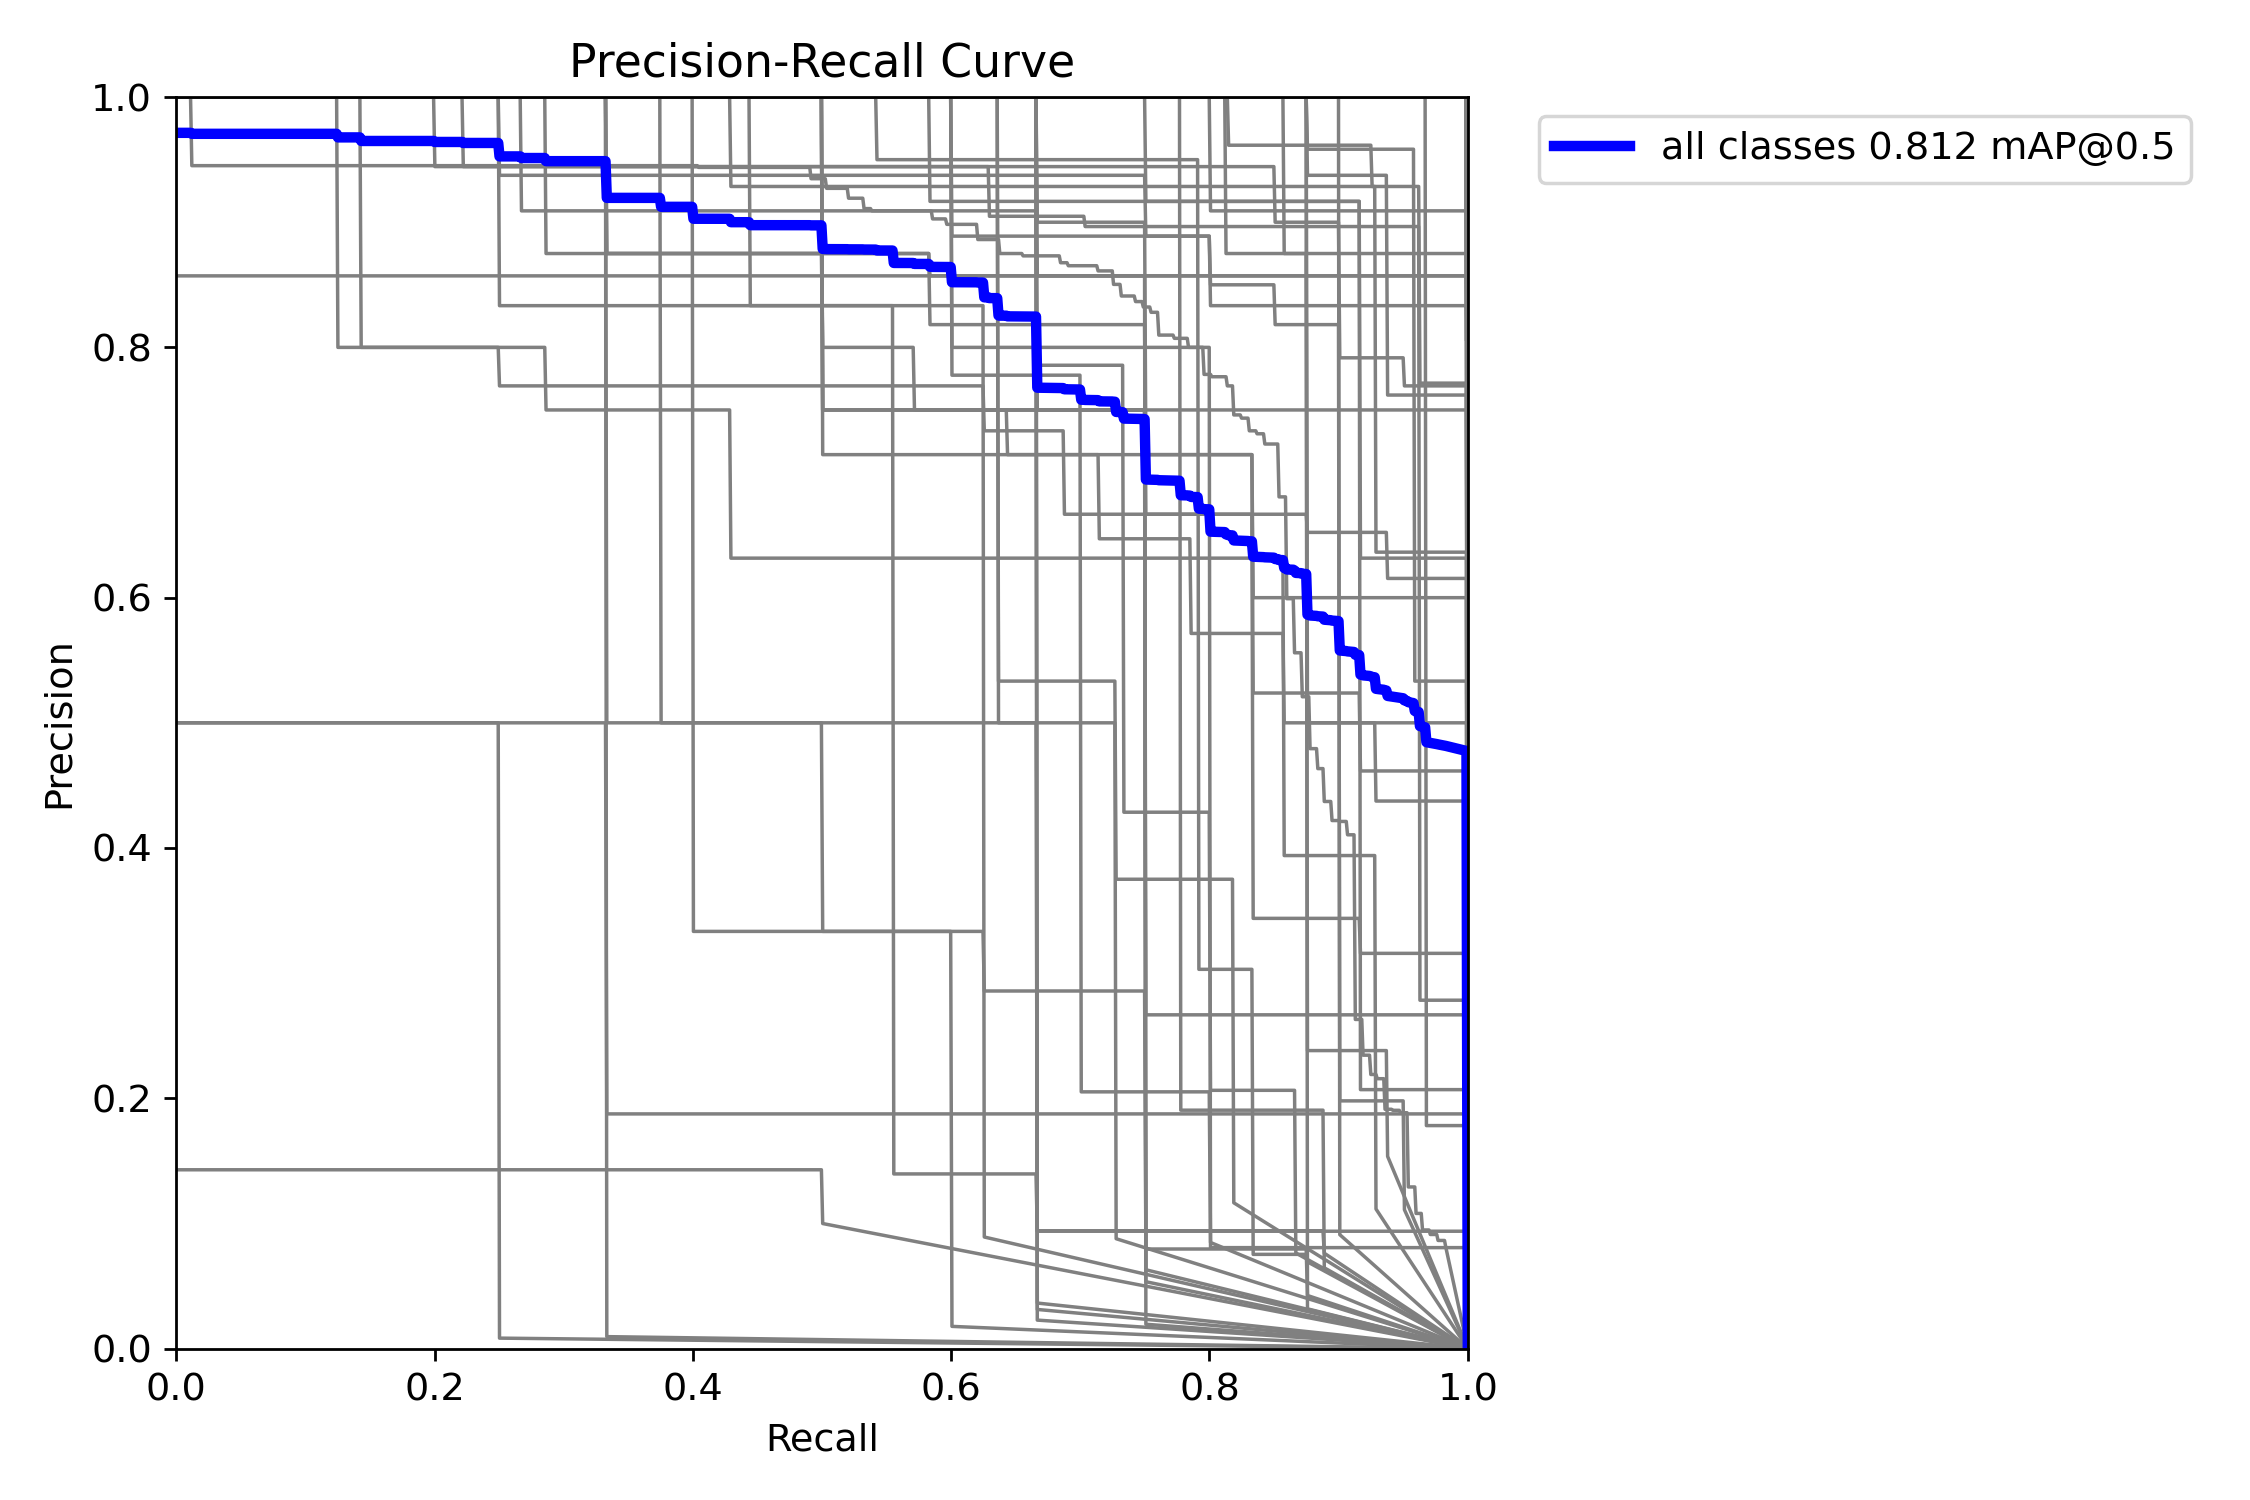

In [ ]:
display(Image(filename='/content/runs/detect/train/BoxPR_curve.png'))

F1 Score Curve

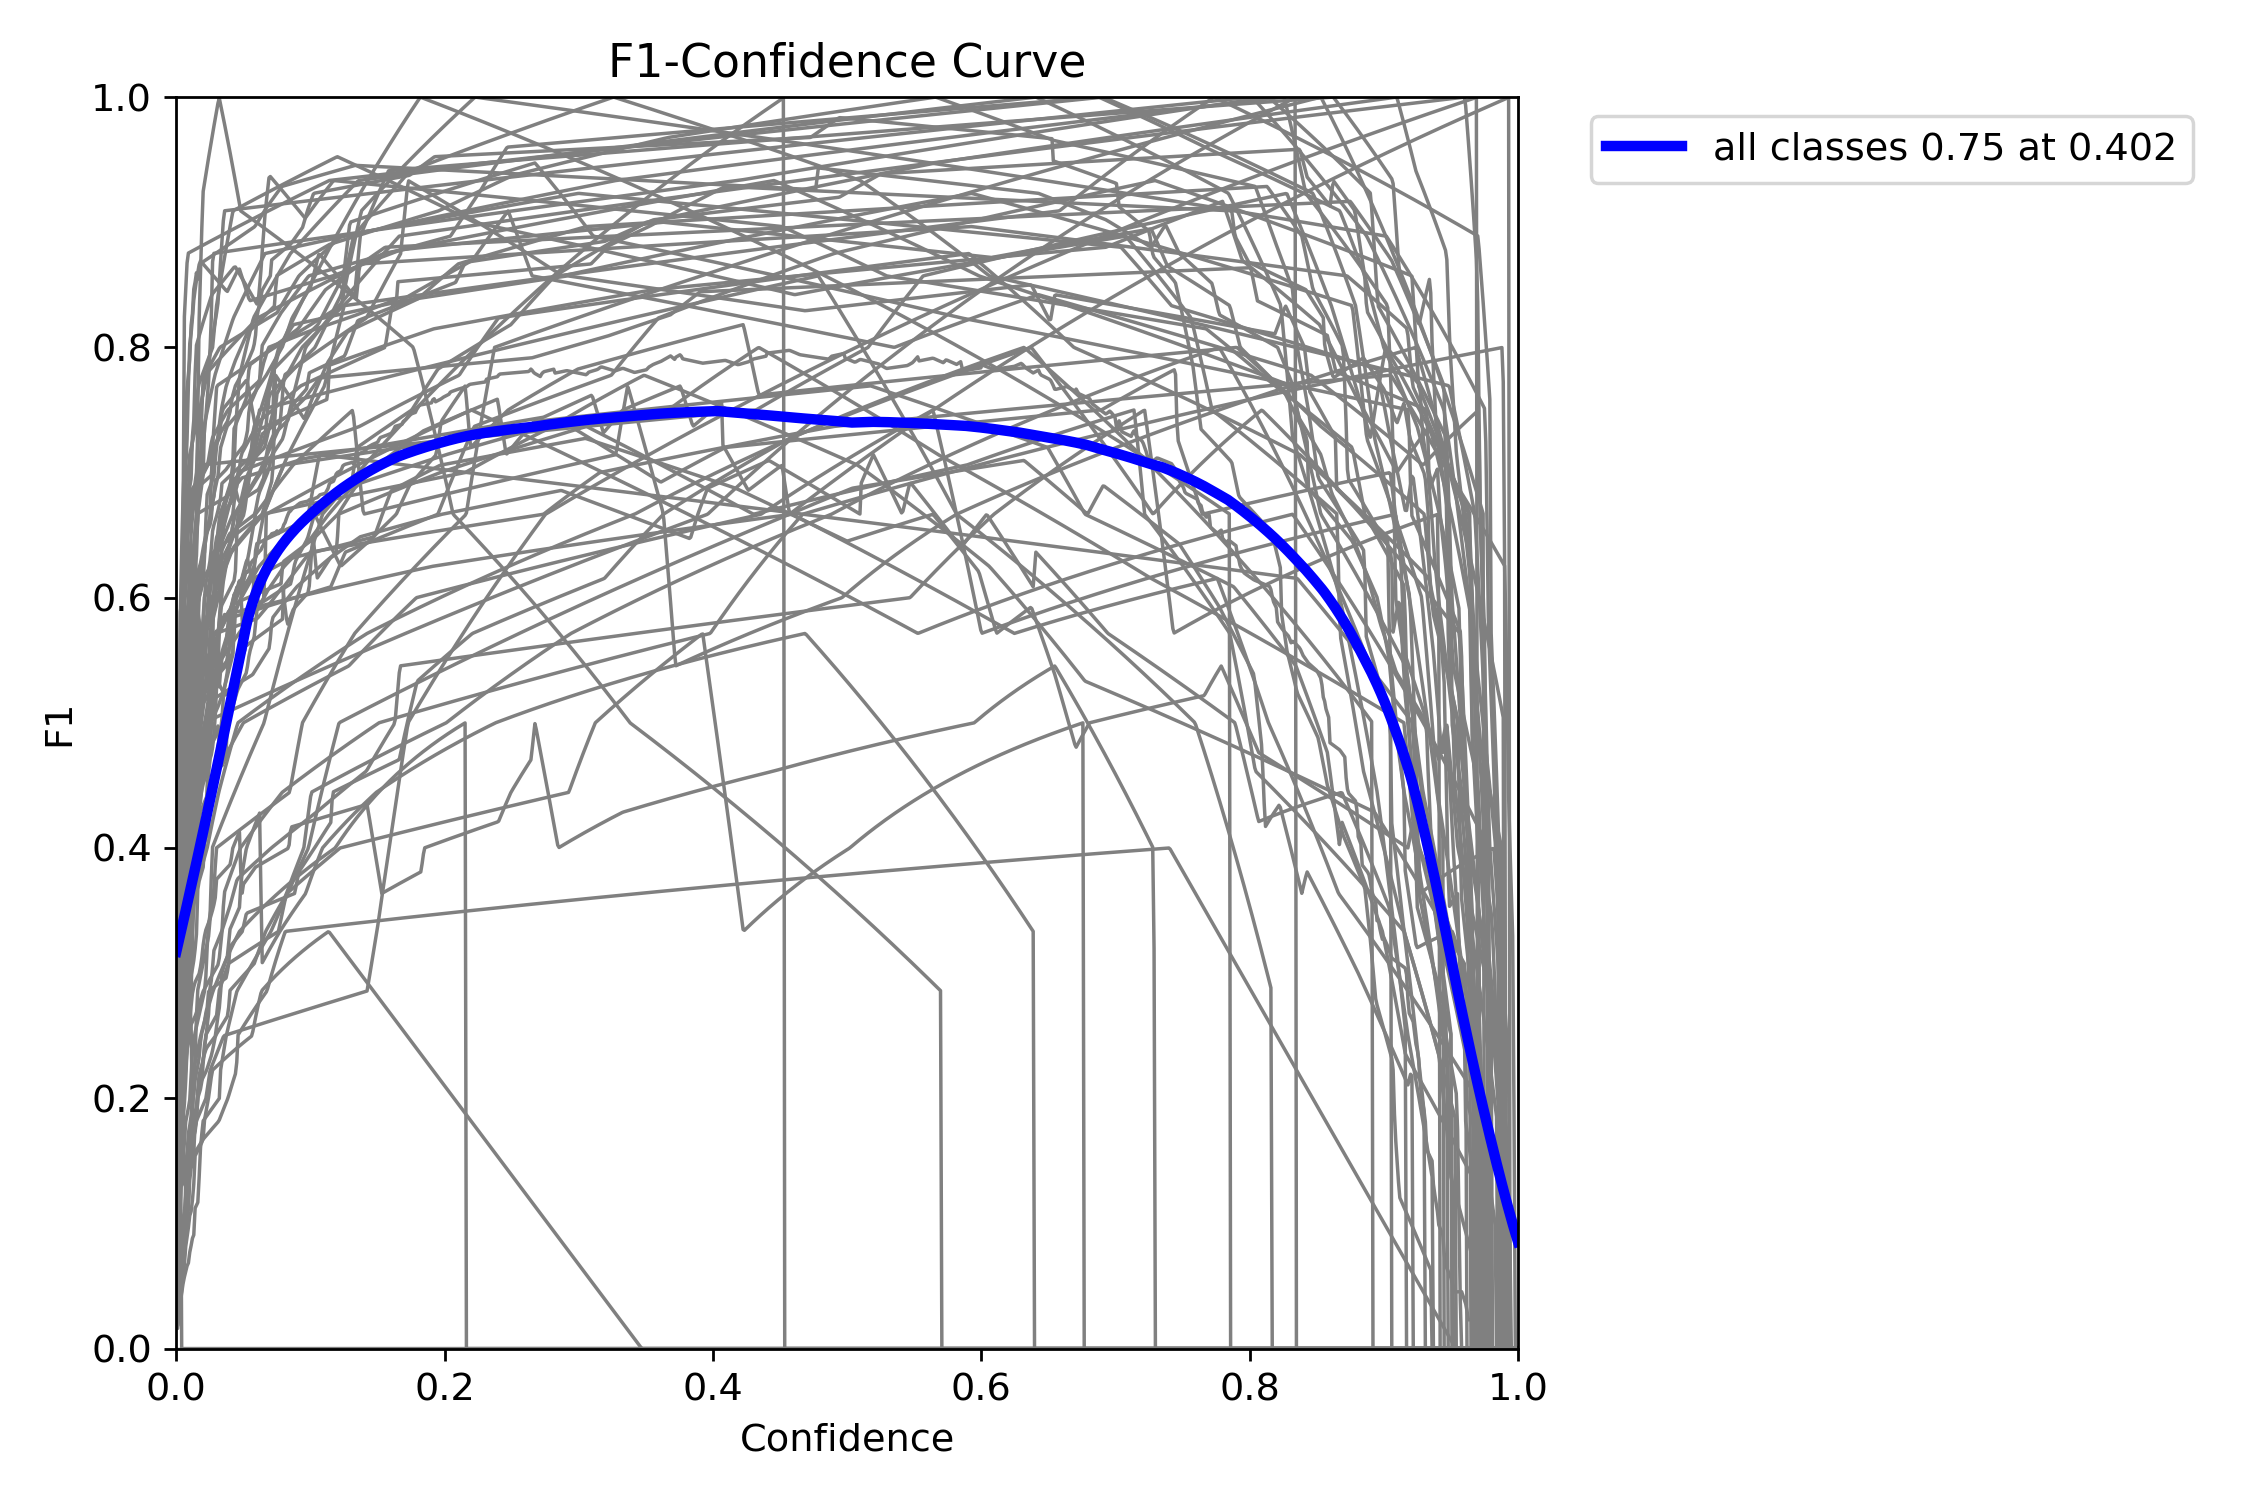

In [ ]:
display(Image(filename='/content/runs/detect/train/BoxF1_curve.png'))

Evaluate Model

In [ ]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.33 =� Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,099,938 parameters, 0 gradients, 8.5 GFLOPs
val: Fast image access  (ping: 1.3�1.3 ms, read: 23.6�20.6 MB/s, size: 39.0 KB)
val: Scanning /content/drive/MyDrive/Traffic-signs dataset/valid/labels.cache... 720 images, 0 backgrounds, 0 corrupt: 100%  720/720 232.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%  45/45 2.8it/s 16.1s
                   all        720        811      0.798      0.773      0.812      0.559
                     -         98        171      0.776      0.801      0.818      0.426
- 50- probability of horizontal flip          6          6      0.635        0.5      0.834      0.541
- 50- probability of vertical flip          8         11      0.826      0.636      0.728      0.428
- Random Gaussian blur of between 0 and 3.25 pixels          8          8      0.983      0.875      0.935   

Test Predictions (Visualization)


In [ ]:
model = YOLO("runs/detect/train/weights/best.pt")

results = model(dataset_path + "/test/images", save=True)


image 1/775 /content/drive/MyDrive/Traffic-signs dataset/test/images/BA-11-_png_jpg.rf.0c99f050c078387e61fb32d10c2e63fc.jpg: 640x640 1 30, 12.6ms
image 2/775 /content/drive/MyDrive/Traffic-signs dataset/test/images/BA-13-_png_jpg.rf.d1fcc73c238819407a0bf03a89093bc8.jpg: 640x640 1 This dataset was exported via roboflow.com on December 23- 2023 at 11-58 AM GMT, 12.7ms
image 3/775 /content/drive/MyDrive/Traffic-signs dataset/test/images/BA-16-_png_jpg.rf.383e88929462808cb8c1f86d8089ee69.jpg: 640x640 1 This dataset was exported via roboflow.com on December 23- 2023 at 11-58 AM GMT, 8.4ms
image 4/775 /content/drive/MyDrive/Traffic-signs dataset/test/images/BA-20-_png_jpg.rf.b9108a27d1f789c600ce3b6ce0460087.jpg: 640x640 1 This dataset was exported via roboflow.com on December 23- 2023 at 11-58 AM GMT, 7.8ms
image 5/775 /content/drive/MyDrive/Traffic-signs dataset/test/images/BA-22-_png_jpg.rf.e0e7d93d9066bc3245f77b4fde0d3af4.jpg: 640x640 1 This dataset was exported via roboflow.com on Decem

Show Predictions

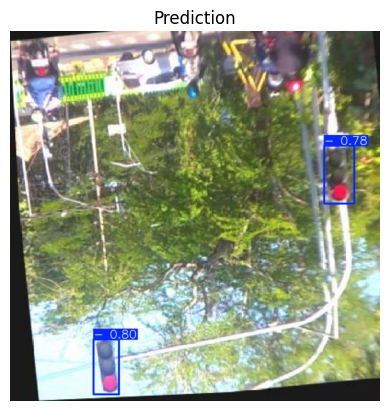

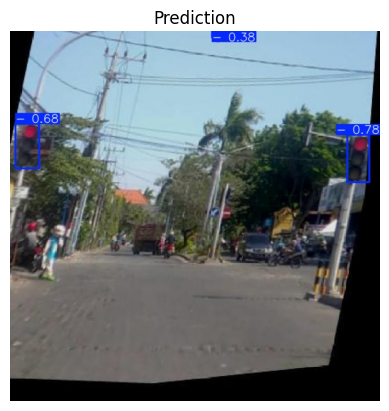

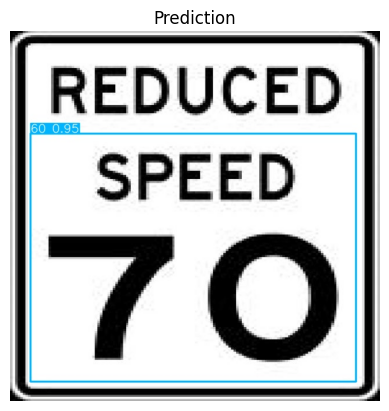

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

pred_folder = "runs/detect/predict"

images = os.listdir(pred_folder)

for i in range(3):  # show 3 images
    img_path = pred_folder + "/" + images[i]
    img = cv2.imread(img_path)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Prediction")
    plt.axis("off")
    plt.show()

Custom Visualization (Bar Chart of Classes)

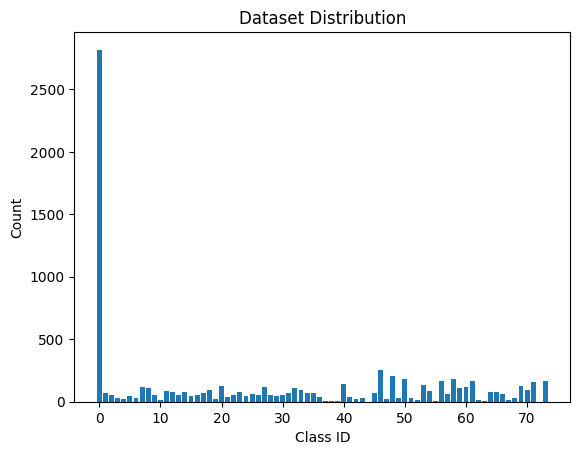

In [ ]:
import os

label_path = dataset_path + "/train/labels"

class_count = {}

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file)) as f:
        for line in f:
            cls = int(line.split()[0])
            class_count[cls] = class_count.get(cls, 0) + 1

# Plot
import matplotlib.pyplot as plt

plt.bar(class_count.keys(), class_count.values())
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.title("Dataset Distribution")
plt.show()

Detection Function

In [ ]:
def detect_sign(image_path):
    results = model(image_path)
    results[0].show()
    return results[0].boxes.cls.tolist()

Run Detection


image 1/1 /content/drive/MyDrive/Traffic-signs dataset/test/images/BA-11-_png_jpg.rf.0c99f050c078387e61fb32d10c2e63fc.jpg: 640x640 1 30, 7.8ms
Speed: 2.2ms preprocess, 7.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


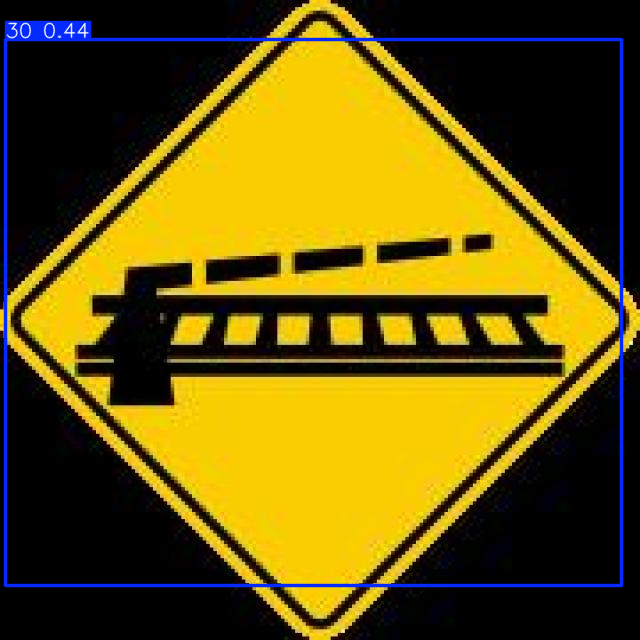

Detected Classes: [20.0]


In [ ]:
image_path = "/content/drive/MyDrive/Traffic-signs dataset/test/images/BA-11-_png_jpg.rf.0c99f050c078387e61fb32d10c2e63fc.jpg"

labels = detect_sign(image_path)
print("Detected Classes:", labels)

#**Integrated YOLO and Reinforcement Learning**

In [1]:
!pip install ultralytics opencv-python gym numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.2 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model = YOLO("yolov8n.pt")  # pretrained model (detects cars, buses, trucks)

In [4]:
def count_vehicles(image_path):
    results = model(image_path)
    count = 0

    for r in results:
        for box in r.boxes:
            cls = int(box.cls[0])
            label = model.names[cls]

            if label in ['car', 'bus', 'truck', 'motorbike']:
                count += 1

    return count, results

In [5]:
class TrafficEnv:
    def __init__(self):
        self.queue = 0
        self.time_step = 0

    def reset(self):
        self.queue = 0
        self.time_step = 0
        return [self.queue]

    def step(self, action, vehicle_count):

        # Add incoming vehicles
        self.queue += vehicle_count

        if action == 1:  # GREEN
            cleared = min(self.queue, 3)  # limit flow
            self.queue -= cleared

        if action == 1:  # GREEN
          if self.queue > 0:
              reward = 1   # good decision (clearing traffic)
          else:
              reward = -1  # wasted green
        else:  # RED
          if self.queue > 3:
              reward = -2  # bad (blocking traffic)
          else:
              reward = 0   # acceptable

        self.time_step += 1
        done = self.time_step > 20

        return [self.queue], reward, done

In [6]:
Q = np.zeros((50, 2))  # states: vehicle count (0–49), actions: 2

alpha = 0.1
gamma = 0.9
epsilon = 0.2

In [9]:
image_list = [
    "1.jpg",
    "2.jpg",
    "3.jpg",
    "4.jpg",
    "5.jpg",
    "6.jpg",
    "7.jpg",
    "8.jpg",
    "9.jpg",
    "10.jpg"
]

In [ ]:
from IPython.display import display
import time

env = TrafficEnv()
episodes = 10


reward_history = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    print(f"\n===== Episode {ep+1} =====")

    for t in range(10):

        image_path = random.choice(image_list)

        #Get vehicle count + YOLO results
        vehicle_count, results = count_vehicles(image_path)

        # simulate realistic density
        #vehicle_count = max(vehicle_count * random.randint(2, 4), 1)

        # Handle zero vehicle case
        if vehicle_count == 0:
            print("No vehicles detected - skipping image")
            continue

        s = min(vehicle_count, 49)

        # Read original image
        original_img = cv2.imread(image_path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

        # YOLO detected image
        annotated = results[0].plot()

        # Plot both images
        fig, axes = plt.subplots(1, 2, figsize=(12,5))

        # Original image
        axes[0].imshow(original_img)
        axes[0].set_title("Original Traffic Image")
        axes[0].axis("off")

        # Detection image
        axes[1].imshow(annotated)
        axes[1].set_title("YOLO Vehicle Detection")
        axes[1].axis("off")

        plt.suptitle(f"Episode {ep+1} | Step {t+1}")
        plt.show()

        # Action selection
        if random.uniform(0,1) < epsilon:
            action = random.choice([0,1])
        else:
            action = np.argmax(Q[s])

        # Environment step
        next_state, reward, done = env.step(action, vehicle_count)
        ns = min(next_state[0], 49)

        # Q update
        Q[s, action] = Q[s, action] + alpha * (
            reward + gamma * np.max(Q[ns]) - Q[s, action]
        )

        state = next_state
        total_reward += reward

        # Display results clearly
        print(f"Step {t+1}")
        print(f"Vehicles Detected: {vehicle_count}")
        if action == 1:
            print("🟢 TRAFFIC LIGHT: GREEN")
        else:
            print("🔴 TRAFFIC LIGHT: RED")
        print(f"Queue After Action: {next_state[0]}")
        print(f"Reward: {reward}")
        print("-"*40)

        time.sleep(1)

        if done:
            break

    reward_history.append(total_reward)
    print(f"\nEpisode {ep+1} Total Reward: {total_reward}")
    print("="*50)

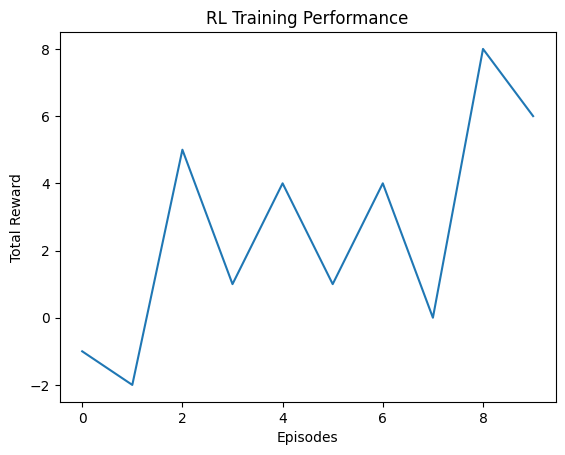

In [11]:
plt.plot(reward_history)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("RL Training Performance")
plt.show()